# 📚 Uygulamalı Makine Öğrenmesi
## Hafta 4 — Destek Vektör Makineleri (SVM)

---

> **Ders Notu Bilgileri**  
> - **Düzey:** Lisans 3-4. Sınıf & Yüksek Lisans  
> - **Süre:** ~3 ders saati  
> - **Önkoşul:** KNN, Lojistik Regresyon, Karar Ağacı bilgisi  
> - **Kütüphaneler:** NumPy · Pandas · Scikit-learn · Plotly · Seaborn · Altair  

---

## 📋 İçindekiler

| # | Konu | Tür |
|---|------|-----|
| 1 | Kütüphane Kurulumu | Kod |
| 2 | SVM Nedir? — Temel Fikir & Özellikler | Teori |
| 3 | Maksimum Marjin & Destek Vektörleri | Teori + Kod |
| 4 | Hard vs Soft Margin — C Parametresi | Teori + Kod |
| 5 | Hinge Loss Nedir? | Teori + Kod |
| 6 | Kernel Trick | Teori + Kod |
| 7 | Kernel Türleri: Linear, RBF, Poly, Sigmoid | Teori + Kod |
| 8 | Veri Setleri | Bilgi |
| 9 | EDA: Breast Cancer | Kod |
| 10 | Veri Ön İşleme | Kod |
| 11 | Pegasos — Sıfırdan SVM (Hinge Loss) | Kod |
| 12 | Scikit-learn LinearSVC | Kod |
| 13 | Scikit-learn SVC (RBF Kernel) | Kod |
| 14 | Kernel Karşılaştırması | Kod |
| 15 | C × γ Hiperparametre Analizi | Kod |
| 16 | GridSearchCV ile Optimizasyon | Kod |
| 17 | Karar Sınırları Görselleştirmesi | Kod |
| 18 | Confusion Matrix & ROC Eğrisi | Kod |
| 19 | SVR — SVM ile Regresyon | Kod |
| 20 | Tüm Modeller Karşılaştırması | Kod |
| 21 | Özet & Sonraki Adımlar | Özet |

---
## 1. 📦 Kütüphane Kurulumu & İçe Aktarma

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import altair as alt

from sklearn.datasets import (load_breast_cancer, load_iris,
    make_circles, make_moons, make_regression)
from sklearn.model_selection import (train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
    classification_report, roc_curve, roc_auc_score,
    f1_score, mean_squared_error, r2_score)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Tüm kütüphaneler yüklendi!')

✅ Tüm kütüphaneler yüklendi!


---
## 2. 🤔 SVM Nedir? — Temel Fikir

**Destek Vektör Makinesi (SVM)**, iki sınıf arasındaki **marjini maksimize eden** hiper düzlem bularak sınıflandırma yapan denetimli öğrenme algoritmasıdır.

### Temel Soru:
Birden fazla hiper düzlem iki sınıfı ayırabiliyorsa **hangisi en iyi?**  
SVM'in cevabı: **Her iki sınıfa da en uzak olanı!** → Maksimum Marjin

### Ana Kavramlar:

| Kavram | Açıklama |
|--------|----------|
| **Hiper Düzlem** | Karar sınırı. 2D'de doğru, 3D'de düzlem, yüksek boyutlarda hiper düzlem |
| **Marjin** | Hiper düzlem ile her iki sınıfın en yakın noktaları arası mesafe |
| **Destek Vektörleri** | Marjin sınırında bulunan kritik veri noktaları |
| **Maksimum Marjin** | SVM'in optimize ettiği hedef |

### Temel Özellikler:

| Özellik | Değer |
|---------|-------|
| **Tür** | Denetimli Öğrenme |
| **Görev** | Sınıflandırma + Regresyon |
| **Ölçeklendirme** | **Zorunlu** |
| **Kernel desteği** | Linear, RBF, Poly, Sigmoid |
| **Yüksek boyut** | Güçlü (kernel trick ile) |
| **Veri boyutu** | Küçük-orta idealdir (N < 100K) |

---
## 3. 📐 Maksimum Marjin & Destek Vektörleri

### Karar Hiper Düzlemi:
$$\mathbf{w}^T \mathbf{x} + b = 0$$

### Marjin Genişliği:
$$\text{Marjin} = \frac{2}{\|\mathbf{w}\|}$$

### Primal Optimizasyon Problemi (Hard Margin):
$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{k.k.} \quad y^{(i)} (\mathbf{w}^T \mathbf{x}^{(i)} + b) \geq 1 \quad \forall i$$

**Yorumlama:**
- $\|\mathbf{w}\|$ küçüldükçe marjin büyür → minimizasyon = marjin maksimizasyonu
- Kısıt: Tüm noktalar doğru tarafta ve marjin dışında
- Sadece **destek vektörleri** kısıtı aktif tutar

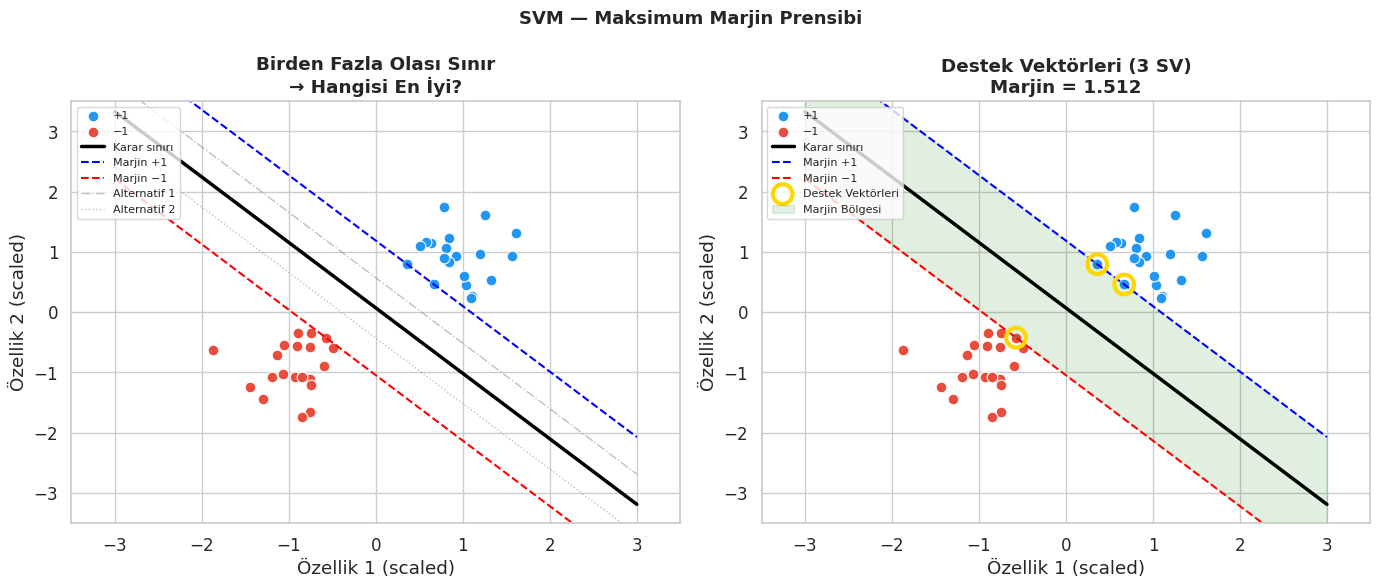

Destek Vektörü Sayısı : [1 2]
Marjin Genişliği      : 1.5123


In [2]:
# ─── Maksimum Marjin Görselleştirmesi ────────────────────────────────────────

np.random.seed(RANDOM_STATE)

# İki sınıflı basit lineer veri
X_pos = np.random.randn(20, 2) + [2.5, 2.5]
X_neg = np.random.randn(20, 2) + [-2.5, -2.5]
X_demo = np.vstack([X_pos, X_neg])
y_demo = np.array([1]*20 + [-1]*20)

# Ölçeklendir ve SVM eğit
sc_demo = StandardScaler()
X_demo_sc = sc_demo.fit_transform(X_demo)
svm_demo = SVC(kernel='linear', C=1e6)   # Büyük C ≈ hard margin
svm_demo.fit(X_demo_sc, y_demo)

w = svm_demo.coef_[0]
b = svm_demo.intercept_[0]
sv = svm_demo.support_vectors_

x_r = np.linspace(-3, 3, 200)
y_dec  = -(w[0]*x_r + b) / w[1]
y_m_p  = -(w[0]*x_r + b - 1) / w[1]
y_m_n  = -(w[0]*x_r + b + 1) / w[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_i, ax in enumerate(axes):
    ax.scatter(X_demo_sc[y_demo==1, 0],  X_demo_sc[y_demo==1, 1],
               c='#2196F3', s=60, edgecolors='w', lw=0.8, label='+1')
    ax.scatter(X_demo_sc[y_demo==-1, 0], X_demo_sc[y_demo==-1, 1],
               c='#E74C3C', s=60, edgecolors='w', lw=0.8, label='−1')
    ax.plot(x_r, y_dec,  'k-',  lw=2.5, label='Karar sınırı')
    ax.plot(x_r, y_m_p,  'b--', lw=1.5, label='Marjin +1')
    ax.plot(x_r, y_m_n,  'r--', lw=1.5, label='Marjin −1')

    if ax_i == 1:
        ax.scatter(sv[:, 0], sv[:, 1], s=200,
                   facecolors='none', edgecolors='gold', lw=3,
                   label='Destek Vektörleri', zorder=4)
        ax.fill_between(x_r, y_m_n, y_m_p,
                        alpha=0.12, color='green', label='Marjin Bölgesi')
        marjin = 2 / np.linalg.norm(w)
        ax.set_title(f'Destek Vektörleri ({svm_demo.n_support_.sum()} SV)\nMarjin = {marjin:.3f}',
                     fontweight='bold')
    else:
        ax.set_title('Birden Fazla Olası Sınır\n→ Hangisi En İyi?', fontweight='bold')
        ax.plot(x_r, y_dec+0.5, 'gray', lw=1, alpha=0.5, ls='-.', label='Alternatif 1')
        ax.plot(x_r, y_dec-0.5, 'gray', lw=1, alpha=0.5, ls=':', label='Alternatif 2')

    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_xlabel('Özellik 1 (scaled)')
    ax.set_ylabel('Özellik 2 (scaled)')

plt.suptitle('SVM — Maksimum Marjin Prensibi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Destek Vektörü Sayısı : {svm_demo.n_support_}')
print(f'Marjin Genişliği      : {2/np.linalg.norm(w):.4f}')

---
## 4. ⚖️ Hard vs Soft Margin — C Parametresi

### Soft Margin Optimizasyon Problemi:
$$\min_{\mathbf{w}, b, \xi} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i} \xi_i$$

$$\text{k.k.} \quad y^{(i)}(\mathbf{w}^T \mathbf{x}^{(i)} + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

| C Değeri | Marjin | Hata Toleransı | Risk |
|----------|--------|----------------|------|
| **Çok küçük** | Geniş | Yüksek | Underfitting |
| **Orta** | Dengeli | Orta | ✅ İdeal |
| **Çok büyük** | Dar | Düşük | Overfitting |

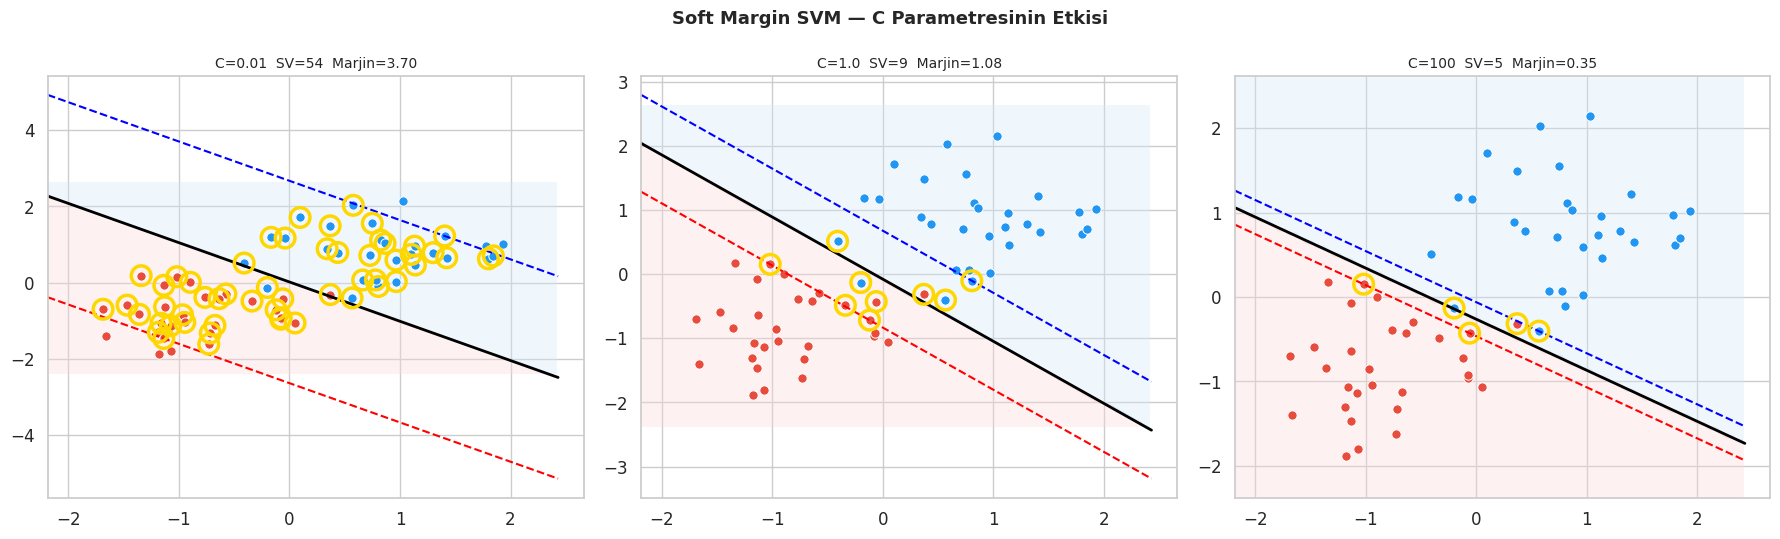

💡 C küçük → geniş marjin | C büyük → dar marjin (hard margin benzeri)


In [4]:
# ─── Soft Margin: Farklı C Değerleri ─────────────────────────────────────────

np.random.seed(7)
X_soft = np.vstack([
    np.random.randn(30,2) + [1.5,1.5],
    np.random.randn(30,2) + [-1.5,-1.5]
])
y_soft = np.array([1]*30 + [-1]*30)
sc_soft = StandardScaler()
X_soft_sc = sc_soft.fit_transform(X_soft)

C_vals = [0.01, 1.0, 100]
h_s = 0.05
x0m, x0M = X_soft_sc[:,0].min()-0.5, X_soft_sc[:,0].max()+0.5
x1m, x1M = X_soft_sc[:,1].min()-0.5, X_soft_sc[:,1].max()+0.5
xx_s, yy_s = np.meshgrid(np.arange(x0m,x0M,h_s), np.arange(x1m,x1M,h_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Soft Margin SVM — C Parametresinin Etkisi', fontsize=13, fontweight='bold')
cml = mcolors.ListedColormap(['#FADBD8','#D6EAF8'])

for ax, C_v in zip(axes, C_vals):
    sv_m = SVC(kernel='linear', C=C_v)
    sv_m.fit(X_soft_sc, y_soft)
    Z_s = sv_m.predict(np.c_[xx_s.ravel(), yy_s.ravel()]).reshape(xx_s.shape)
    ax.contourf(xx_s, yy_s, Z_s, alpha=0.35, cmap=cml)
    w_s = sv_m.coef_[0]; b_s = sv_m.intercept_[0]
    xr_s = np.linspace(x0m, x0M, 100)
    ax.plot(xr_s, -(w_s[0]*xr_s+b_s)/w_s[1],   'k-',  lw=2)
    ax.plot(xr_s, -(w_s[0]*xr_s+b_s-1)/w_s[1], 'b--', lw=1.5)
    ax.plot(xr_s, -(w_s[0]*xr_s+b_s+1)/w_s[1], 'r--', lw=1.5)
    ax.scatter(X_soft_sc[y_soft==1,0], X_soft_sc[y_soft==1,1],
               c='#2196F3', s=45, edgecolors='w', lw=0.7)
    ax.scatter(X_soft_sc[y_soft==-1,0], X_soft_sc[y_soft==-1,1],
               c='#E74C3C', s=45, edgecolors='w', lw=0.7)
    ax.scatter(sv_m.support_vectors_[:,0], sv_m.support_vectors_[:,1],
               s=200, facecolors='none', edgecolors='gold', lw=2.5, zorder=4)
    marj = 2/np.linalg.norm(w_s)
    ax.set_title(f'C={C_v}  SV={sv_m.n_support_.sum()}  Marjin={marj:.2f}', fontsize=10)

plt.tight_layout()
plt.show()
print('💡 C küçük → geniş marjin | C büyük → dar marjin (hard margin benzeri)')

Soft Margin SVM — C Parametresinin Etkisi

Bu görsel, Destek Vektör Makinesi'nde (SVM) C (düzenlileştirme) parametresinin karar sınırı ve marjin üzerindeki etkisini üç farklı değerle karşılaştırmalı olarak göstermektedir.

C=0.01 durumunda model çok toleranslı davranır; 54 destek vektörüyle son derece geniş bir marjin (3.70) oluşturulmuş, ancak pek çok nokta yanlış tarafta kalmıştır — yani sınıflandırma hataları görmezden gelinerek genelleme ön plana çıkarılmıştır. C=1.0 durumunda denge kurulmuş; 9 destek vektörü ve 1.08'lik makul bir marjinle hem esneklik hem doğruluk bir arada sağlanmıştır. C=100 durumunda ise model hatalara karşı çok katı hale gelir; sadece 5 destek vektörüyle marjin 0.35'e kadar daralır ve karar sınırı neredeyse tüm eğitim noktalarını doğru sınıflandırmaya zorlanır, bu da aşırı öğrenme (overfitting) riskini artırır. Özetle, C küçüldükçe marjin genişler ve model daha az hassas ama daha genel, C büyüdükçe marjin daralır ve model eğitim verisine daha sıkı uyar.

---
## 5. 📉 Hinge Loss

SVM, MSE veya Cross-Entropy yerine **Hinge Loss** kullanır:

$$L_{\text{hinge}}(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})$$

**Primal Objektif (Soft Margin):**
$$\mathcal{L} = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{N}\sum_i \max(0, 1 - y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)}+b))$$

**Hinge Loss'un Özellikleri:**
- Fonksiyonel marjin $\geq 1$ ise → **sıfır kayıp**
- Sadece marjin içinde veya yanlış taraftaki noktalar katkı sağlar
- Lojistik Reg.'a göre seyrek çözüm → yalnızca SV'ler önemli

In [5]:
# ─── Hinge Loss vs Cross-Entropy Görselleştirmesi ────────────────────────────

z_range = np.linspace(-3, 3, 500)   # fonksiyonel marjin
hinge   = np.maximum(0, 1 - z_range)
log_l   = np.log(1 + np.exp(-z_range))

fig = go.Figure()
fig.add_trace(go.Scatter(x=z_range, y=hinge, mode='lines',
    line=dict(color='#E74C3C', width=3), name='Hinge Loss: max(0, 1−z)  [SVM]'))
fig.add_trace(go.Scatter(x=z_range, y=log_l, mode='lines',
    line=dict(color='#2196F3', width=3, dash='dash'), name='Log Loss [Lojistik Reg.]'))
fig.add_vline(x=0, line_dash='dot', line_color='gray',
              annotation_text='Karar sınırı (z=0)')
fig.add_vline(x=1, line_dash='dot', line_color='green',
              annotation_text='Marjin (z=1)')
fig.update_layout(
    title='Hinge Loss vs Log Loss',
    xaxis_title='y · (wᵀx + b)  [Fonksiyonel Marjin]',
    yaxis_title='Kayıp', xaxis_range=[-3,3], yaxis_range=[-0.1,4],
    height=420, template='plotly_white')
fig.show()
print('💡 z≥1 bölgesinde hinge loss = 0 — SVM yalnızca marjin içindeki noktaları önemser!')

💡 z≥1 bölgesinde hinge loss = 0 — SVM yalnızca marjin içindeki noktaları önemser!


Hinge Loss ve Log Loss Karşılaştırması

Bu grafik, SVM'de kullanılan Hinge Loss ile Lojistik Regresyon'da kullanılan Log Loss kayıp fonksiyonlarını fonksiyonel marjin ekseninde karşılaştırmaktadır.

Hinge Loss (kırmızı düz çizgi), $$z = y \cdot (w^Tx + b)$$ değeri 1'e ulaştığında tamamen sıfırlanır ve sonrasında sıfırda sabit kalır. Yani model bir noktayı yeterli güvenle (marjin içinde) doğru sınıflandırdığında ceza tamamen kalkar — bu SVM'nin seyrek destek vektörü yapısını açıklar. Karar sınırında (z=0) kayıp 1, negatif bölgede ise doğrusal olarak artar.

Log Loss (mavi kesik çizgi) ise hiçbir zaman tam olarak sıfıra ulaşmaz; z ne kadar büyük olursa olsun asimptotik olarak sıfıra yaklaşır ama dokunmaz. Bu, lojistik regresyonun her zaman tüm noktalar üzerinden öğrenmeye devam ettiği anlamına gelir.

İki fonksiyonun temel farkı şudur: Hinge Loss, marjin dışındaki doğru sınıflandırmaları tamamen yok sayar (sparse gradient), Log Loss ise tüm örneklerden sürekli sinyal alır. Bu nedenle SVM genellikle daha keskin karar sınırları üretirken, lojistik regresyon olasılıksal çıktılar için daha uygundur.

---
## 6. 🔮 Kernel Trick

### Problem: Doğrusal Ayrılamayan Veri
Çözüm: Veriyi yüksek boyutlu uzaya map'le → orada doğrusal ayrıl!

$$K(\mathbf{x}, \mathbf{z}) = \phi(\mathbf{x})^T \phi(\mathbf{z})$$

$\phi(\cdot)$ fonksiyonu **hiç hesaplanmaz** — sadece iç çarpımı hesaplayan $K$ kullanılır.  
Bu sayede sonsuz boyutlu uzaylarda bile çalışabilir!

**Örnek:** Polinom kernel d=2:
$$K(x, z) = (x^T z)^2 \equiv \phi(x) = (x_1^2, \sqrt{2}x_1x_2, x_2^2)$$

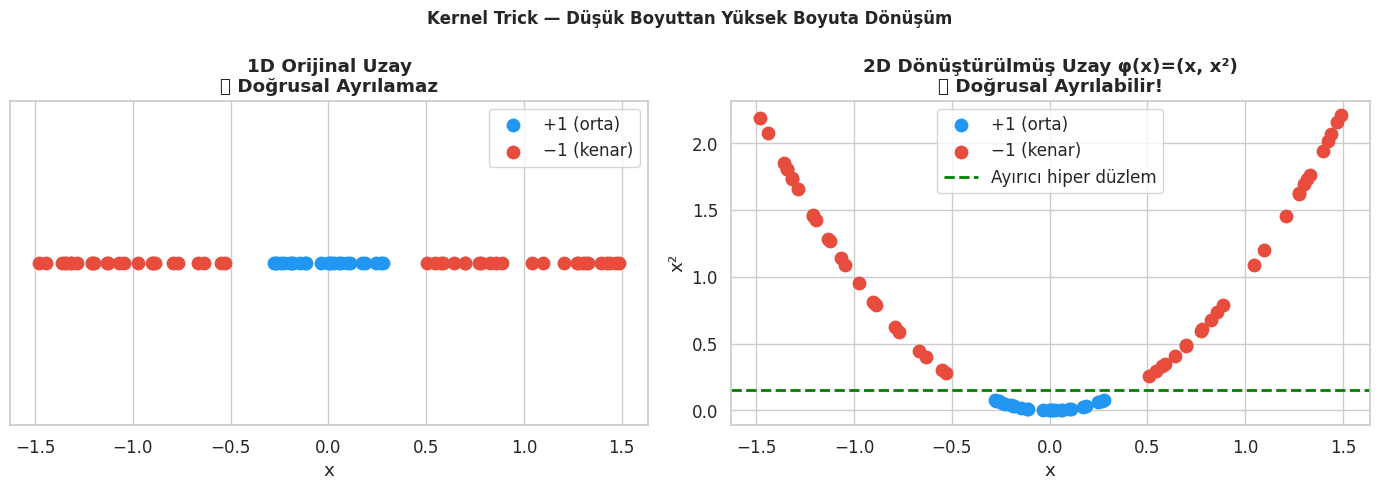

In [6]:
# ─── Kernel Trick: 1D → 2D Dönüşüm Örneği ───────────────────────────────────

np.random.seed(RANDOM_STATE)
X_1d = np.concatenate([
    np.random.uniform(-1.5, -0.5, 25),
    np.random.uniform(-0.3,  0.3, 25),
    np.random.uniform( 0.5,  1.5, 25),
])
y_1d = np.array([-1]*25 + [1]*25 + [-1]*25)

# φ(x) = (x, x²)
X_2d_map = np.column_stack([X_1d, X_1d**2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(X_1d[y_1d==1],  np.zeros(25)+0.02, c='#2196F3', s=80, label='+1 (orta)')
ax.scatter(X_1d[y_1d==-1], np.zeros(50)+0.02, c='#E74C3C', s=80, label='−1 (kenar)')
ax.set_yticks([])
ax.set_title('1D Orijinal Uzay\n❌ Doğrusal Ayrılamaz', fontweight='bold')
ax.set_xlabel('x'); ax.legend()

ax = axes[1]
ax.scatter(X_2d_map[y_1d==1, 0],  X_2d_map[y_1d==1, 1],
           c='#2196F3', s=80, label='+1 (orta)')
ax.scatter(X_2d_map[y_1d==-1, 0], X_2d_map[y_1d==-1, 1],
           c='#E74C3C', s=80, label='−1 (kenar)')
ax.axhline(0.15, color='green', lw=2, ls='--', label='Ayırıcı hiper düzlem')
ax.set_title('2D Dönüştürülmüş Uzay φ(x)=(x, x²)\n✅ Doğrusal Ayrılabilir!', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('x²'); ax.legend()

plt.suptitle('Kernel Trick — Düşük Boyuttan Yüksek Boyuta Dönüşüm', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Kernel Trick — Düşük Boyuttan Yüksek Boyuta Dönüşüm

Bu grafik, Kernel Trick'in temel mantığını çok sade bir örnekle gözler önüne seriyor.

Sol grafik (1D): Veri tek boyutlu bir doğru üzerinde dizilmiş; mavi noktalar ortada, kırmızılar ise her iki yanda yer alıyor. Bu düzenlemede iki sınıfı birbirinden ayıracak tek bir kesme noktası bulmak mümkün değil — yani veri doğrusal olarak ayrılamaz.

Sağ grafik (2D): Aynı veriye $$\varphi(x) = (x,\ x^2)$$ dönüşümü uygulandığında her nokta 2 boyutlu uzaya taşınır. Kırmızı noktalar parabolik bir kol oluşturarak yukarı çıkarken, mavi noktalar $$x^2 \approx 0$$ civarında, yani parabol'un dibinde kalır. Artık yatay yeşil kesik çizgiyle iki sınıf tek bir düz çizgiyle mükemmel biçimde ayrılabiliyor.

Kernel Trick'in özü şudur: yüksek boyutlu dönüşümü açıkça hesaplamak zorunda kalmadan, iç çarpım hesabı üzerinden bu ayrımı verimli şekilde gerçekleştirmek. Bu sayede SVM, doğrusal olmayan karar sınırlarını düşük hesaplama maliyetiyle öğrenebilir.

---
## 7. 🎛️ Kernel Türleri

| Kernel | Formül | γ Etkisi | Kullanım |
|--------|--------|----------|----------|
| **Linear** | $K=\mathbf{x}^T\mathbf{z}$ | — | Doğrusal, büyük veri |
| **RBF** | $K=\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$ | Büyük→keskin | Genel amaçlı default |
| **Poly d** | $K=(\gamma\mathbf{x}^T\mathbf{z}+r)^d$ | — | Polinom ilişki |
| **Sigmoid** | $K=\tanh(\gamma\mathbf{x}^T\mathbf{z}+r)$ | — | NN benzeri |

### RBF Kernel γ Parametresi:
- $\gamma$ büyük → tek nokta etkisi dar → **overfitting**
- $\gamma$ küçük → geniş etki → **underfitting**
- `gamma='scale'`: $\gamma = 1/(d \cdot \text{Var}(X))$ → **önerilen default**

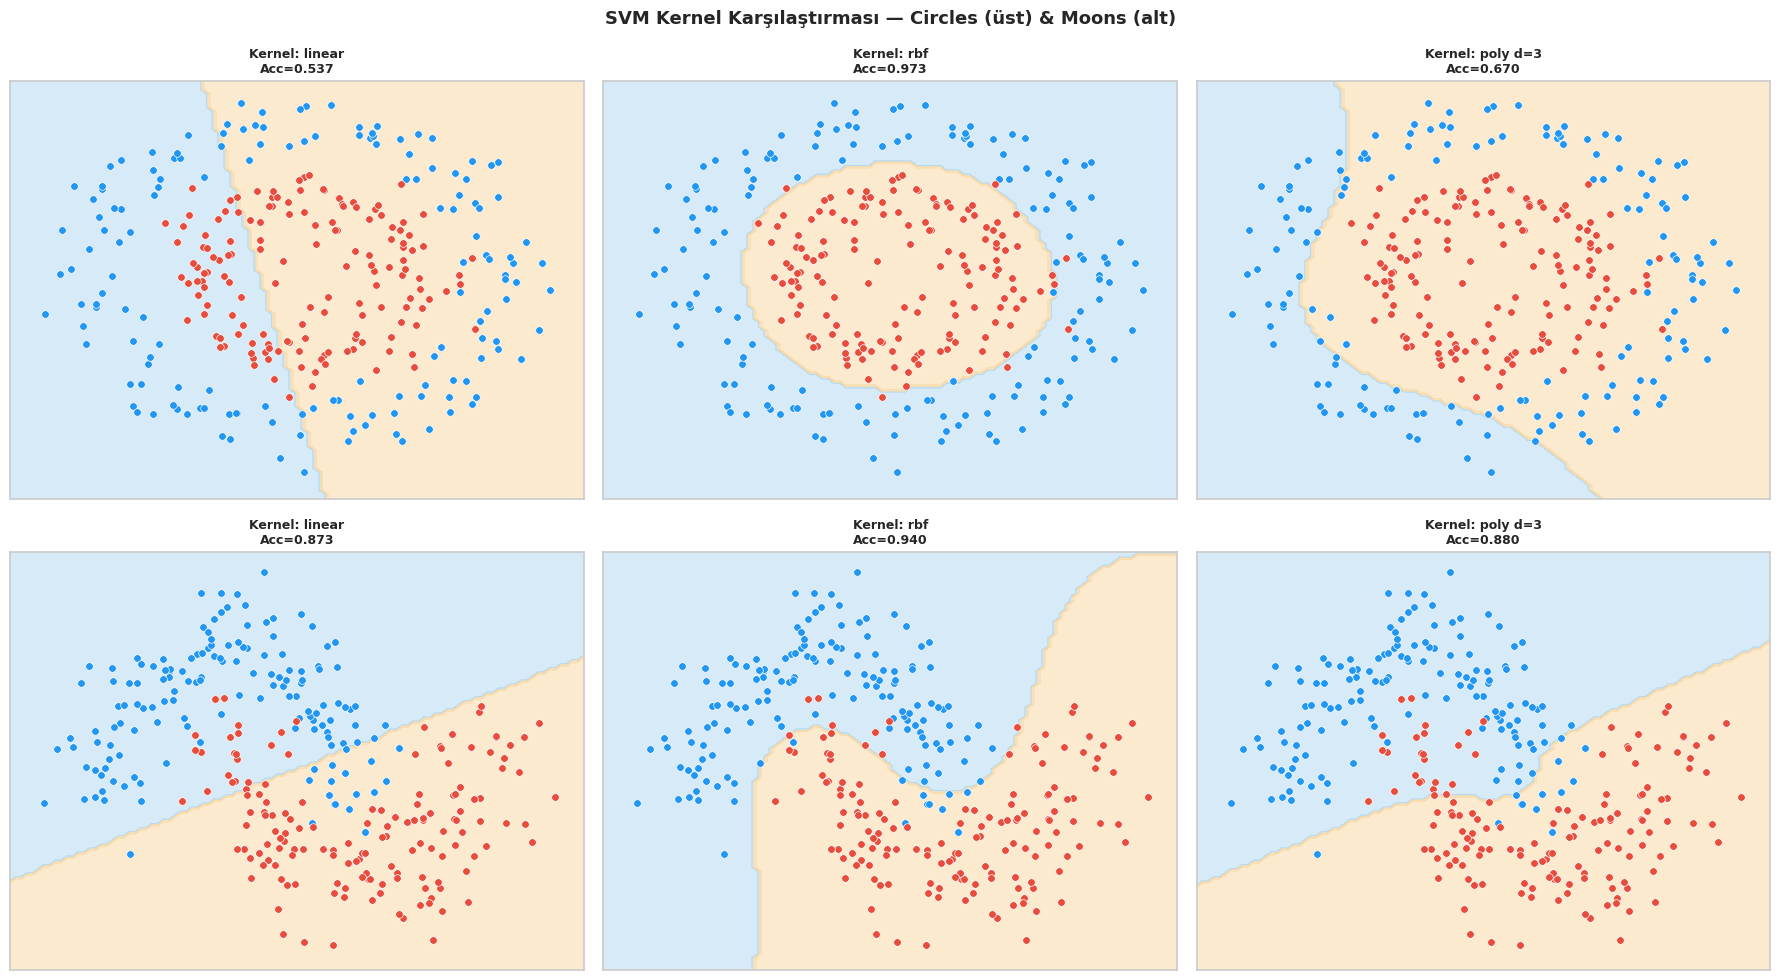

💡 Linear kernel circles/moons üzerinde başarısız — RBF gerekli!


In [7]:
# ─── Kernel Karşılaştırması — Circles & Moons Sentetik Veri ─────────────────

X_circ, y_circ = make_circles(n_samples=300, noise=0.12,
                               factor=0.5, random_state=RANDOM_STATE)
X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=RANDOM_STATE)

sc_c = StandardScaler(); X_circ_sc = sc_c.fit_transform(X_circ)
sc_m = StandardScaler(); X_moon_sc = sc_m.fit_transform(X_moon)

klist = [
    ('linear',   SVC(kernel='linear', C=1.0)),
    ('rbf',      SVC(kernel='rbf', C=1.0, gamma='scale')),
    ('poly d=3', SVC(kernel='poly', degree=3, C=1.0)),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SVM Kernel Karşılaştırması — Circles (üst) & Moons (alt)',
             fontsize=13, fontweight='bold')

cmap_2 = mcolors.ListedColormap(['#AED6F1','#FAD7A0'])
c2 = ['#2196F3','#E74C3C']

for col, (kname, ksvm) in enumerate(klist):
    for row, (Xk, yk) in enumerate([(X_circ_sc, y_circ), (X_moon_sc, y_moon)]):
        ax = axes[row][col]
        km = SVC(kernel=ksvm.kernel, C=ksvm.C,
                 gamma=getattr(ksvm, 'gamma', 'scale'),
                 degree=getattr(ksvm, 'degree', 3))
        km.fit(Xk, yk)
        h2 = 0.05
        xm2,xM2 = Xk[:,0].min()-0.3, Xk[:,0].max()+0.3
        ym2,yM2 = Xk[:,1].min()-0.3, Xk[:,1].max()+0.3
        xx2,yy2 = np.meshgrid(np.arange(xm2,xM2,h2), np.arange(ym2,yM2,h2))
        Z2 = km.predict(np.c_[xx2.ravel(),yy2.ravel()]).reshape(xx2.shape)
        ax.contourf(xx2,yy2,Z2, alpha=0.5, cmap=cmap_2)
        for cls,c in enumerate(c2):
            ax.scatter(Xk[yk==cls,0], Xk[yk==cls,1],
                       c=c, s=30, edgecolors='w', lw=0.5)
        acc2 = km.score(Xk, yk)
        ax.set_title(f'Kernel: {kname}\nAcc={acc2:.3f}', fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
print('💡 Linear kernel circles/moons üzerinde başarısız — RBF gerekli!')

SVM Kernel Karşılaştırması — Circles & Moons

Bu görsel, üç farklı kernel fonksiyonunun iki klasik doğrusal olmayan veri seti üzerindeki performansını karşılaştırıyor.

Circles Veri Seti (Üst Satır)

Bir sınıf diğerini tamamen çevreleyen iç içe halkalar yapısı — doğası gereği radyal simetrik bir problem.

| Kernel | Doğruluk | Yorum |
|---|---|---|
| Linear | 0.537 | Neredeyse rastgele tahmin; düz çizgi bu yapıyı çözemiyor |
| RBF | 0.973 | Mükemmel; dairesel karar sınırı veriye tam uyuyor |
| Poly d=3 | 0.670 | Kısmen başarılı ama yetersiz |

Moons Veri Seti (Alt Satır)

İki yarım ay şeklinde iç içe geçmiş yapı — kıvrımlı ama radyal değil.

| Kernel | Doğruluk | Yorum |
|---|---|---|
| Linear | 0.873 | Şaşırtıcı biçimde makul; moons verisi kısmen doğrusal ayrılabilir |
| RBF | 0.940 | Yine en iyi; esnek karar sınırı kıvrımlara uyum sağlıyor |
| Poly d=3 | 0.880 | RBF'ye yakın, kabul edilebilir performans |

Genel Çıkarım

RBF kernel her iki veri setinde de en yüksek doğruluğu vermiş; bu da onun yerel benzerliklere duyarlı, esnek yapısının doğrusal olmayan problemlerde neden varsayılan tercih olduğunu açıkça gösteriyor. Linear kernel ise geometrik yapıya uymadığında neredeyse işe yaramaz hale geliyor — özellikle Circles'daki %53.7 bu durumun çarpıcı bir kanıtı.

---
## 8. 🗃️ Kullanılan Veri Setleri

### 📌 Breast Cancer Wisconsin
| Bilgi | Detay |
|-------|-------|
| **Kaynak** | W.H. Wolberg et al. (1992), UCI ML Repository |
| **URL** | https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin |
| **Scikit-learn** | `sklearn.datasets.load_breast_cancer()` |
| **Boyut** | 569 × 30 özellik, 2 sınıf |
| **Amaç** | SVM ikili sınıflandırma, ROC analizi |

### 📌 Iris
| Scikit-learn | `sklearn.datasets.load_iris()` | 150×4, 3 sınıf |

### 📌 Sentetik Veri
| `make_circles()` | Kernel trick gerekliliği |
| `make_moons()` | Doğrusal olmayan sınır |

In [8]:
# ─── Veri Yükle ──────────────────────────────────────────────────────────────

cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print('=== VERİ SETLERİ ===')
print(f'Breast Cancer : {X_cancer.shape}  {Counter(y_cancer)}')
print(f'Iris          : {X_iris.shape}   {Counter(y_iris)}')

=== VERİ SETLERİ ===
Breast Cancer : (569, 30)  Counter({np.int64(1): 357, np.int64(0): 212})
Iris          : (150, 4)   Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})


---
## 9. 🔍 EDA: Breast Cancer

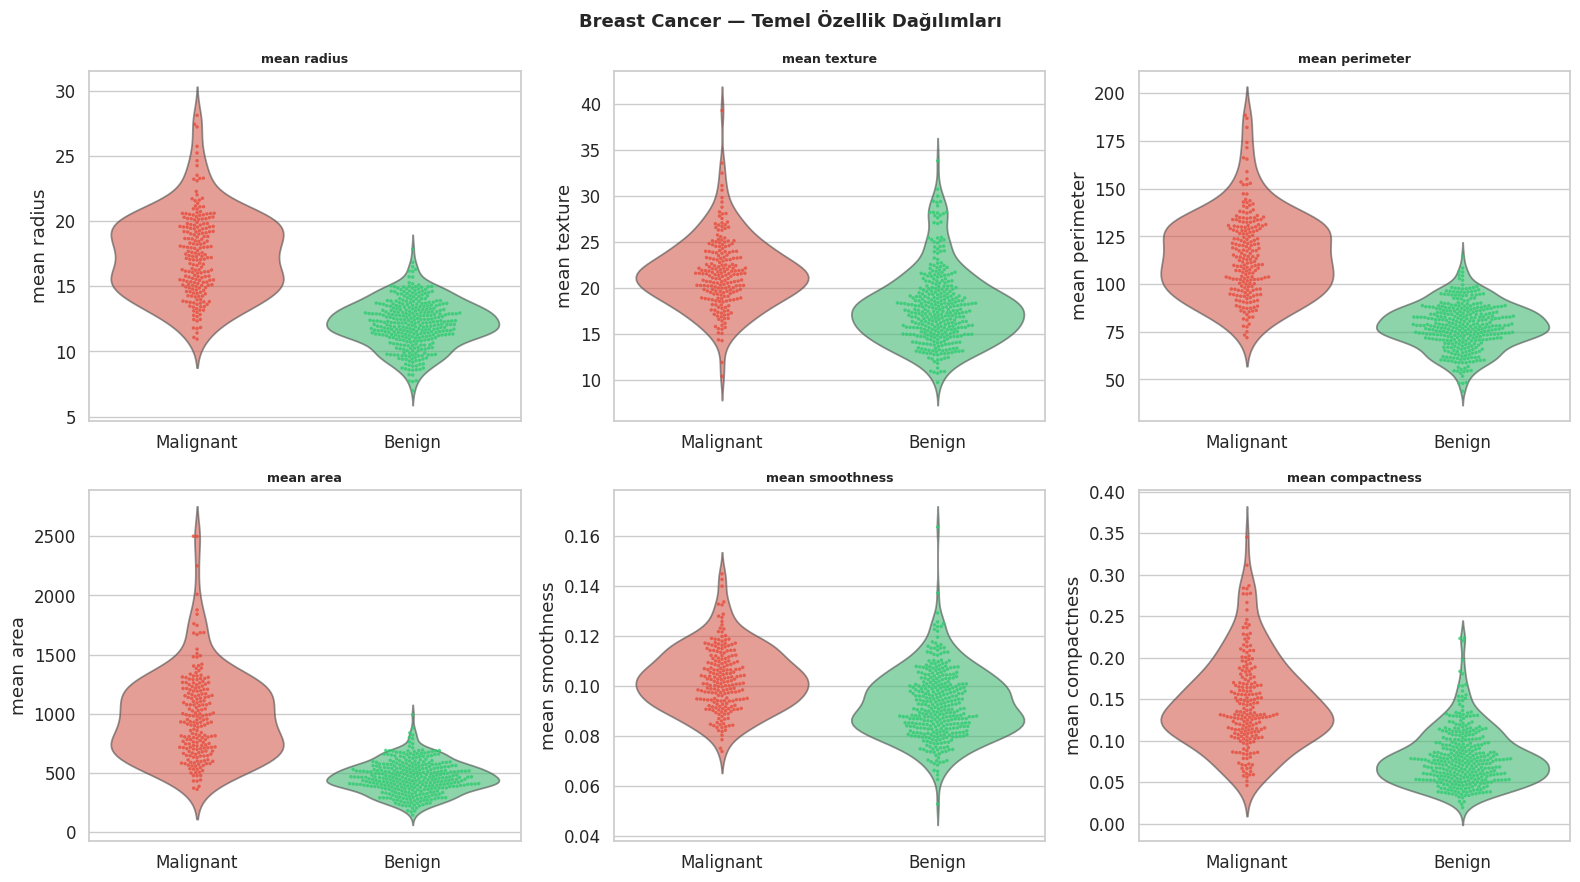

💡 Mean concave points ve mean radius sınıfları güçlü biçimde ayırıyor!


In [9]:
# ─── Violin + Swarm: Sınıflara Göre Özellik Dağılımı ─────────────────────────

df_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_c['target']    = cancer.target
df_c['diagnosis'] = df_c['target'].map({0:'Malignant',1:'Benign'})

key6 = list(cancer.feature_names[:6])
pal  = {'Malignant':'#E74C3C','Benign':'#2ECC71'}

fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.ravel()
fig.suptitle('Breast Cancer — Temel Özellik Dağılımları', fontsize=13, fontweight='bold')

for i, feat in enumerate(key6):
    sns.violinplot(data=df_c, x='diagnosis', y=feat,
                   palette=pal, ax=axes[i], inner=None, alpha=0.6)
    sns.swarmplot(data=df_c, x='diagnosis', y=feat,
                  palette=pal, ax=axes[i], size=2.5, alpha=0.8)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()
print('💡 Mean concave points ve mean radius sınıfları güçlü biçimde ayırıyor!')

In [10]:
# ─── Altair: Korelasyon Isı Haritası (İlk 10 Özellik) ───────────────────────

top10 = list(cancer.feature_names[:10])
corr  = df_c[top10].corr().round(2)

corr_long = corr.reset_index().melt('index')
corr_long.columns = ['var1','var2','corr']
short = {f: f.replace('mean ','').replace(' ','\n') for f in top10}
corr_long['var1'] = corr_long['var1'].map(short)
corr_long['var2'] = corr_long['var2'].map(short)

hm = alt.Chart(corr_long, title='Korelasyon Matrisi — İlk 10 Özellik').mark_rect().encode(
    x=alt.X('var1:N', sort=None, axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('var2:N', sort=None),
    color=alt.Color('corr:Q', scale=alt.Scale(scheme='redblue',domain=[-1,1])),
    tooltip=['var1:N','var2:N',alt.Tooltip('corr:Q',format='.2f')]
).properties(width=380, height=340)

txt = hm.mark_text(fontSize=10).encode(
    text=alt.Text('corr:Q',format='.2f'),
    color=alt.condition(alt.datum.corr>0.6, alt.value('white'), alt.value('black'))
)

(hm+txt).configure_title(fontSize=12).show()
print('💡 Yüksek korelasyonlu özellikler SVM için bilgi tekrarı yaratır.')

alt.LayerChart(...)

💡 Yüksek korelasyonlu özellikler SVM için bilgi tekrarı yaratır.


---
## 10. 🔧 Veri Ön İşleme

SVM **uzaklık tabanlı** — ölçeklendirme **zorunlu**!

In [11]:
# ─── Train-Test Split ────────────────────────────────────────────────────────

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cancer, y_cancer,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_cancer
)

print(f'Eğitim : {X_tr.shape[0]} örnek  |  {Counter(y_tr)}')
print(f'Test   : {X_te.shape[0]} örnek  |  {Counter(y_te)}')

Eğitim : 455 örnek  |  Counter({np.int64(1): 285, np.int64(0): 170})
Test   : 114 örnek  |  Counter({np.int64(1): 72, np.int64(0): 42})


In [12]:
# ─── StandardScaler — fit() SADECE eğitimde! ─────────────────────────────────

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print('Ölçeklendirme Sonrası:')
print(f'  Eğitim — μ (ilk 3): {X_tr_sc.mean(axis=0)[:3].round(4)}  ← ~0')
print(f'  Eğitim — σ (ilk 3): {X_tr_sc.std(axis=0)[:3].round(4)}   ← ~1')

Ölçeklendirme Sonrası:
  Eğitim — μ (ilk 3): [-0.  0. -0.]  ← ~0
  Eğitim — σ (ilk 3): [1. 1. 1.]   ← ~1


---
## 11. 🛠️ Pegasos Algoritması — Sıfırdan SVM

**Pegasos (Primal Estimated sub-GrAdient SOlver)**, Hinge Loss + L2 regularization'ı stokastik gradyan inişiyle optimize eder:

$$\mathcal{L} = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{N}\sum_i \max(0, 1-y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)}+b))$$

Öğrenme hızı değişken: $\eta_t = 1/(\lambda t)$

In [13]:
# ─── Başlangıç Parametreleri ──────────────────────────────────────────────────

N_SAMPLES, N_FEATURES = X_tr_sc.shape
w_peg  = np.zeros(N_FEATURES)
b_peg  = 0.0
LAMBDA = 0.001     # regularization (≈ 1/C)
EPOCHS = 100

# y: {-1, +1} formatı (SVM için)
y_tr_s = np.where(y_tr == 0, -1, 1)
y_te_s = np.where(y_te == 0, -1, 1)

print(f'N={N_SAMPLES}, d={N_FEATURES}, λ={LAMBDA}')

N=455, d=30, λ=0.001


In [14]:
# ─── Pegasos Eğitim Döngüsü ──────────────────────────────────────────────────

loss_hist = []
t = 1

for epoch in range(EPOCHS):
    idx = np.random.permutation(N_SAMPLES)

    for i in idx:
        eta = 1.0 / (LAMBDA * t)
        t  += 1

        # Fonksiyonel marjin hesapla
        margin = y_tr_s[i] * (np.dot(w_peg, X_tr_sc[i]) + b_peg)

        if margin < 1:   # Hinge loss aktif
            w_peg = w_peg - eta*LAMBDA*w_peg + eta*y_tr_s[i]*X_tr_sc[i]
            b_peg = b_peg + eta*y_tr_s[i]
        else:             # Sadece regularization
            w_peg = w_peg - eta*LAMBDA*w_peg

    # Epoch sonu kayıp
    margins  = y_tr_s * (X_tr_sc @ w_peg + b_peg)
    hinge    = np.maximum(0, 1 - margins).mean()
    reg      = (LAMBDA/2) * np.dot(w_peg, w_peg)
    loss_hist.append(hinge + reg)

# Test doğruluğu
y_peg_pred = np.sign(X_te_sc @ w_peg + b_peg)
acc_peg    = (y_peg_pred == y_te_s).mean()

print(f'Son Kayıp        : {loss_hist[-1]:.4f}')
print(f'Test Doğruluğu   : {acc_peg:.4f} ({acc_peg*100:.1f}%)')

Son Kayıp        : 45.7719
Test Doğruluğu   : 0.9035 (90.4%)


In [15]:
# ─── Pegasos Kayıp Eğrisi ────────────────────────────────────────────────────

fig = go.Figure(go.Scatter(
    x=list(range(EPOCHS)), y=loss_hist,
    mode='lines', line=dict(color='#E74C3C', width=2.5)
))
fig.update_layout(
    title='Pegasos — Kayıp Eğrisi (Hinge + Regularization)',
    xaxis_title='Epoch', yaxis_title='Kayıp',
    height=380, template='plotly_white'
)
fig.show()

Pegasos — Kayıp Eğrisi

Bu grafik, Pegasos algoritmasının (Primal Estimated sub-GrAdient SOlver for SVM) eğitim sürecinde toplam kayıp değerinin epoch'lara göre nasıl değiştiğini gösteriyor.

Kayıp fonksiyonu Hinge Loss + L2 Regularization bileşiminden oluşuyor:

$$L(w) = \lambda \|w\|^2 + \frac{1}{n}\sum{i=1}^{n} \max(0,\ 1 - yi(w^T xi))$$

Eğri üç aşamalı bir davranış sergiliyor:

• 0–10. epoch: Kayıp ~165'ten ~95'e çok hızlı düşüyor. Bu, ağırlık vektörünün başlangıçta tamamen rastgele olmasından kaynaklanan büyük gradyan adımlarıyla açıklanır.
• 10–40. epoch: Düşüş yavaşlıyor; model giderek daha iyi bir çözüme yaklaşıyor, öğrenme hızı da $$η
t = \frac{1}{\lambda t}$$ formülüyle epoch başına otomatik küçülüyor.
• 40–100. epoch: Eğri neredeyse düzleşiyor ve ~45 civarında bir platoya oturuyor; yakınsama gerçekleşmiş, anlamlı iyileşme kalmamış.

Genel tablo sağlıklı bir eğitimi yansıtıyor: ani bir başlangıç düşüşü ve düzgün bir yakınsama, herhangi bir salınım veya ıraksama yok. Pegasos'un stokastik yapısının getirdiği gürültü de bu ölçekte görünür değil; eğri oldukça pürüzsüz seyretmiş.

---
## 12. 🔬 Scikit-learn: LinearSVC

In [16]:
# ─── LinearSVC: Büyük Veri İçin Hızlı SVM ────────────────────────────────────
# LinearSVC liblinear'ı kullanır → SVC(kernel='linear')'den çok daha hızlı

lsvc = LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE)
lsvc.fit(X_tr_sc, y_tr)

acc_lsvc = accuracy_score(y_te, lsvc.predict(X_te_sc))
print(f'LinearSVC Test Acc : {acc_lsvc:.4f}  |  n_iter={lsvc.n_iter_}')

LinearSVC Test Acc : 0.9649  |  n_iter=9


---
## 13. 🔬 Scikit-learn: SVC (RBF Kernel)

In [17]:
# ─── SVC: Kernel SVM ─────────────────────────────────────────────────────────

svc_rbf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',     # 1/(n_features * Var(X))
    probability=True,  # ROC için
    random_state=RANDOM_STATE
)
svc_rbf.fit(X_tr_sc, y_tr)

y_pred_svc = svc_rbf.predict(X_te_sc)
y_prob_svc = svc_rbf.predict_proba(X_te_sc)[:, 1]
acc_svc    = accuracy_score(y_te, y_pred_svc)

print(f'SVC (RBF) — kernel={svc_rbf.kernel}, C={svc_rbf.C}, γ={svc_rbf.gamma}')
print(f'Destek Vektör Sayısı: {svc_rbf.n_support_}  (sınıf başına)')
print(f'Toplam SV           : {svc_rbf.support_vectors_.shape[0]}')
print(f'Test Doğruluğu      : {acc_svc:.4f} ({acc_svc*100:.1f}%)')
print()
print(classification_report(y_te, y_pred_svc, target_names=['Malignant','Benign']))

SVC (RBF) — kernel=rbf, C=1.0, γ=scale
Destek Vektör Sayısı: [51 46]  (sınıf başına)
Toplam SV           : 97
Test Doğruluğu      : 0.9825 (98.2%)

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
## 14. 🔄 Kernel Karşılaştırması — Breast Cancer

In [18]:
# ─── Kernel CV Karşılaştırması ───────────────────────────────────────────────

kconfigs = [
    ('linear',    SVC(kernel='linear',  C=1.0, random_state=RANDOM_STATE)),
    ('rbf',       SVC(kernel='rbf',     C=1.0, gamma='scale', random_state=RANDOM_STATE)),
    ('poly d=2',  SVC(kernel='poly', degree=2, C=1.0, random_state=RANDOM_STATE)),
    ('poly d=3',  SVC(kernel='poly', degree=3, C=1.0, random_state=RANDOM_STATE)),
    ('sigmoid',   SVC(kernel='sigmoid', C=1.0, random_state=RANDOM_STATE)),
]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kres = []

for kn, km in kconfigs:
    s = cross_val_score(km, X_tr_sc, y_tr, cv=cv5, scoring='f1', n_jobs=-1)
    km.fit(X_tr_sc, y_tr)
    kres.append({'Kernel':kn, 'CV F1 Ort':round(s.mean(),4),
                 'CV F1 Std':round(s.std(),4),
                 'Test Acc':round(km.score(X_te_sc,y_te),4)})

df_kres = pd.DataFrame(kres).sort_values('CV F1 Ort', ascending=False)
display(df_kres)

,Kernel,CV F1 Ort,CV F1 Std,Test Acc
1,rbf,0.9738,0.0122,0.9825
0,linear,0.9721,0.0125,0.9737
4,sigmoid,0.9721,0.0101,0.9298
3,poly d=3,0.9228,0.0216,0.9123
2,poly d=2,0.8696,0.0103,0.8158


Kernel Performans Karşılaştırması

Tablo, 5 farklı kernel'in çapraz doğrulama (CV) F1 skoru ve test doğruluğunu özetliyor.

RBF hem CV F1 hem de test doğruluğunda açık ara birinci; CV ile test skoru arasındaki fark da küçük (0.9738 → 0.9825), yani genelleme başarılı.

Linear CV'de RBF ile neredeyse eşit (0.9721 vs 0.9738) ama test'te belirgin bir düşüş var (0.9737). Veri muhtemelen büyük ölçüde doğrusal ayrılabilir, bu yüzden linear bu kadar iyi.

Sigmoid CV'de linear ile aynı skoru paylaşıyor ancak test doğruluğu oldukça düşük (0.9298) — CV sırasında görünmeyen dağılım kayması ya da kernel'in veri geometrisine zayıf uyumu bunu açıklıyor.

Poly d=3 ve d=2 her iki metrikte de geride kalıyor. Özellikle d=2'nin CV std'si düşük ama skoru da düşük — tutarlı biçimde kötü performans, yani varyans değil bias problemi var.

Sonuç olarak bu veri seti için RBF kernel açık tercih, linear ise hesaplama maliyeti önemli olduğunda makul bir alternatif.

---
## 15. 🎛️ C × γ Hiperparametre Analizi

RBF kernel için **C** ve **γ** birlikte optimize edilmeli — ikisi birbirini etkiler.

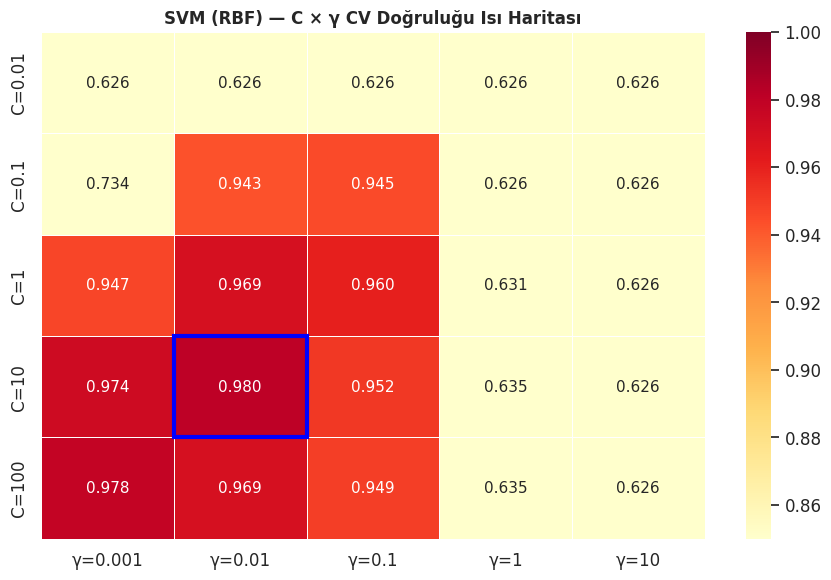

En iyi: C=10, γ=0.01, CV=0.9802


In [19]:
# ─── C × γ Isı Haritası ──────────────────────────────────────────────────────

C_range     = [0.01, 0.1, 1, 10, 100]
gamma_range = [0.001, 0.01, 0.1, 1, 10]
score_mat   = np.zeros((len(C_range), len(gamma_range)))

for i, Cv in enumerate(C_range):
    for j, gv in enumerate(gamma_range):
        sc = cross_val_score(
            SVC(kernel='rbf', C=Cv, gamma=gv, random_state=RANDOM_STATE),
            X_tr_sc, y_tr, cv=5, scoring='accuracy', n_jobs=-1
        ).mean()
        score_mat[i, j] = sc

df_hm = pd.DataFrame(score_mat,
    index=[f'C={c}' for c in C_range],
    columns=[f'γ={g}' for g in gamma_range])

fig, ax = plt.subplots(figsize=(9,6))
sns.heatmap(df_hm, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0.85, vmax=1.0,
            annot_kws={'size':11})
ax.set_title('SVM (RBF) — C × γ CV Doğruluğu Isı Haritası', fontsize=12, fontweight='bold')

bi = np.unravel_index(score_mat.argmax(), score_mat.shape)
ax.add_patch(plt.Rectangle((bi[1],bi[0]),1,1,fill=False,edgecolor='blue',lw=3))
plt.tight_layout()
plt.show()
print(f'En iyi: C={C_range[bi[0]]}, γ={gamma_range[bi[1]]}, CV={score_mat[bi]:.4f}')

---
## 16. 🔍 GridSearchCV ile Optimizasyon

In [20]:
# ─── GridSearchCV: C, γ, kernel birlikte ────────────────────────────────────

param_g = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale','auto',0.01,0.1],
    'kernel': ['rbf','linear']
}

gs = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_g, cv=5, scoring='f1', n_jobs=-1
)
gs.fit(X_tr_sc, y_tr)

print('=== GridSearchCV ===')
print(f'  En iyi parametre: {gs.best_params_}')
print(f'  CV F1             : {gs.best_score_:.4f}')
print(f'  Test Acc          : {gs.best_estimator_.score(X_te_sc,y_te):.4f}')

=== GridSearchCV ===
  En iyi parametre: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  CV F1             : 0.9845
  Test Acc          : 0.9825


---
## 17. 🗺️ Karar Sınırları — Iris Verisi

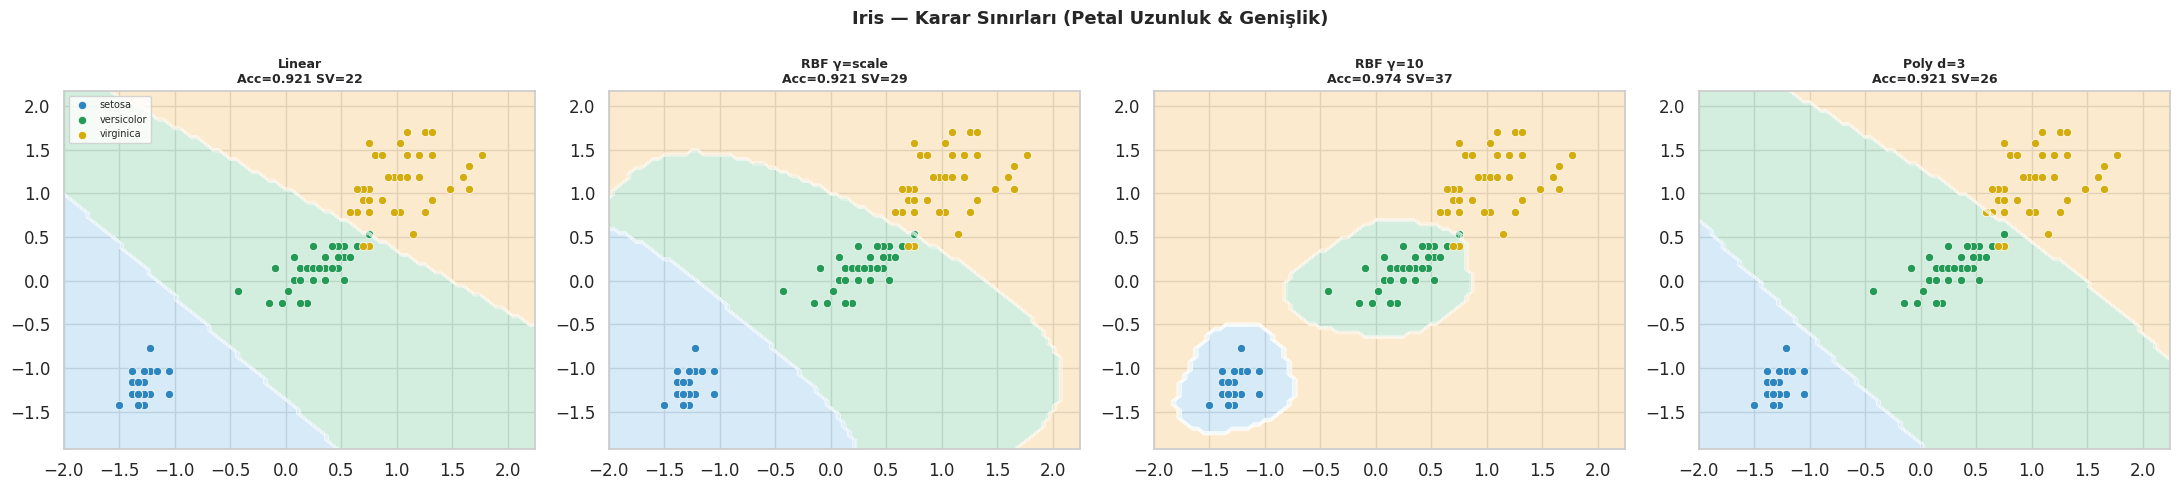

💡 RBF γ=10: Aşırı keskin — overfitting  |  γ=scale: Dengeli


In [21]:
# ─── Karar Sınırları: 4 Kernel ───────────────────────────────────────────────

X_2f = iris.data[:, 2:]   # petal özellikleri
y_2f = iris.target

X_2f_tr, X_2f_te, y_2f_tr, y_2f_te = train_test_split(
    X_2f, y_2f, test_size=0.25, random_state=RANDOM_STATE, stratify=y_2f
)
sc2 = StandardScaler()
X_2f_tr_sc = sc2.fit_transform(X_2f_tr)
X_2f_te_sc = sc2.transform(X_2f_te)

kir = [
    ('Linear',        SVC(kernel='linear', C=1.0)),
    ('RBF γ=scale',   SVC(kernel='rbf', C=1.0, gamma='scale')),
    ('RBF γ=10',      SVC(kernel='rbf', C=1.0, gamma=10)),
    ('Poly d=3',      SVC(kernel='poly', degree=3, C=1.0)),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Iris — Karar Sınırları (Petal Uzunluk & Genişlik)', fontsize=13, fontweight='bold')
cmap3 = mcolors.ListedColormap(['#AED6F1','#A9DFBF','#FAD7A0'])
c3 = ['#2E86C1','#239B56','#D4AC0D']

h4 = 0.05
xm4,xM4 = X_2f_tr_sc[:,0].min()-0.5, X_2f_tr_sc[:,0].max()+0.5
ym4,yM4 = X_2f_tr_sc[:,1].min()-0.5, X_2f_tr_sc[:,1].max()+0.5
xx4,yy4 = np.meshgrid(np.arange(xm4,xM4,h4), np.arange(ym4,yM4,h4))

for ax, (kn, ks) in zip(axes, kir):
    ks.fit(X_2f_tr_sc, y_2f_tr)
    Z4 = ks.predict(np.c_[xx4.ravel(),yy4.ravel()]).reshape(xx4.shape)
    ax.contourf(xx4,yy4,Z4, alpha=0.5, cmap=cmap3)
    ax.contour(xx4,yy4,Z4, colors='white', linewidths=0.5)
    for cls,c in enumerate(c3):
        m = y_2f_tr==cls
        ax.scatter(X_2f_tr_sc[m,0], X_2f_tr_sc[m,1],
                   c=c, s=35, edgecolors='w', lw=0.5, label=iris.target_names[cls])
    acc4 = ks.score(X_2f_te_sc,y_2f_te)
    ax.set_title(f'{kn}\nAcc={acc4:.3f} SV={ks.n_support_.sum()}',
                 fontweight='bold', fontsize=9)

axes[0].legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()
print('💡 RBF γ=10: Aşırı keskin — overfitting  |  γ=scale: Dengeli')

Iris — Karar Sınırları Karşılaştırması

Bu grafik, Iris veri setinin Petal Uzunluk & Genişlik uzayında 4 farklı SVM kernel'inin oluşturduğu karar sınırlarını gösteriyor.

Kernel'lerin Karşılaştırması

Linear (Acc=0.921, SV=22)
Üç sınıfı düz çizgilerle ayırıyor. Setosa (mavi) kolayca ayrılmış, asıl zorluk versicolor–virginica sınırında. 22 destek vektörüyle en seyrek model; sınırlar temiz ve yorumlanabilir.

RBF γ=scale (Acc=0.921, SV=29)
Görsel olarak linear'a çok benziyor, doğruluk aynı (0.921) ama 29 SV kullanıyor. γ değerinin düşük kalması nedeniyle kernel fazla esneklik kazanamamış, neredeyse doğrusal bir sınır ortaya çıkmış.

RBF γ=10 (Acc=0.974, SV=37)
En yüksek doğruluk. γ'nın büyük olması kernel'i çok lokal hale getiriyor; her sınıf etrafında adacık benzeri, organik şekilli bölgeler oluşuyor. Setosa ve versicolor kümelerinin sınırları veriyi neredeyse sarmış durumda. En fazla SV (37) bu esnekliğin bedeli.

Poly d=3 (Acc=0.921, SV=26)
Karar sınırları eğrisel ama RBF γ=10 kadar lokal değil. Doğruluk linear ve RBF γ=scale ile aynı (0.921); polinom yapısı bu veri geometrisine ekstra katkı sağlamamış.

Genel Çıkarım

Buradaki kritik ders γ'nın etkisi: aynı RBF kernel, γ=scale ile 0.921'de kalırken γ=10 ile 0.974'e çıkıyor. Ancak çok yüksek γ aşırı öğrenme riskini de beraberinde getirir — her küme etrafındaki dar adacıklar yeni veriye karşı kırılgan olabilir. Linear kernel ise en az SV ile en yorumlanabilir ve rekabetçi sonucu sunuyor.

---
## 18. 📊 Confusion Matrix & ROC

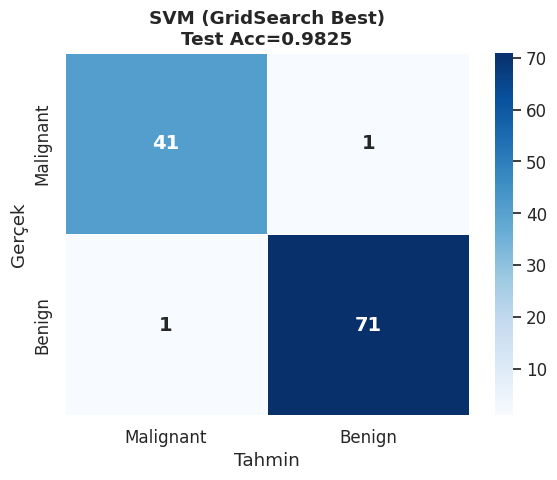

In [22]:
# ─── Confusion Matrix ────────────────────────────────────────────────────────

y_best = gs.best_estimator_.predict(X_te_sc)
cm     = confusion_matrix(y_te, y_best)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'],
            linewidths=0.5, ax=ax,
            annot_kws={'size':14,'weight':'bold'})
ax.set_title(f'SVM (GridSearch Best)\nTest Acc={accuracy_score(y_te,y_best):.4f}', fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.show()

Confusion Matrix

GridSearch ile optimize edilmiş SVM, test setinde %98.25 doğruluk elde etmiş. 114 örnekten sadece 2 tanesi yanlış sınıflandırılmış:

Tahmin: Malignant	Tahmin: Benign
Gerçek: Malignant	41 ✓	1 ✗
Gerçek: Benign	1 ✗	71 ✓
Her iki hata da simetriktir — birer False Negative (malignant'ı benign sanmak) ve birer False Positive var. Tıbbi bağlamda False Negative daha kritiktir çünkü kanseri gözden kaçırmak demek; bu açıdan tek hata oldukça iyi bir sonuç.

In [23]:
# ─── ROC Eğrisi — SVM vs LR ──────────────────────────────────────────────────

y_prob_best = gs.best_estimator_.predict_proba(X_te_sc)[:,1]
fpr_s, tpr_s, _ = roc_curve(y_te, y_prob_best)
auc_s = roc_auc_score(y_te, y_prob_best)

lr_r = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_r.fit(X_tr_sc, y_tr)
fpr_l, tpr_l, _ = roc_curve(y_te, lr_r.predict_proba(X_te_sc)[:,1])
auc_l = roc_auc_score(y_te, lr_r.predict_proba(X_te_sc)[:,1])

fig = go.Figure()
for fpr,tpr,auc,name,color in [
    (fpr_s,tpr_s,auc_s,'SVM GS Best','#E74C3C'),
    (fpr_l,tpr_l,auc_l,'Lojistik Reg','#2196F3')
]:
    fig.add_trace(go.Scatter(x=fpr,y=tpr,mode='lines',
        line=dict(color=color,width=2.5),
        name=f'{name} (AUC={auc:.4f})'))

fig.add_trace(go.Scatter(x=[0,1],y=[0,1],mode='lines',
    line=dict(color='gray',dash='dash'),name='Rastgele'))
fig.update_layout(title='ROC Eğrisi — SVM vs Lojistik Regresyon',
    xaxis_title='FPR', yaxis_title='TPR',
    height=430, template='plotly_white')
fig.show()
print(f'SVM AUC: {auc_s:.4f}  |  LR AUC: {auc_l:.4f}')

SVM AUC: 0.9937  |  LR AUC: 0.9954


ROC Eğrisi

İki model de olağanüstü performans gösteriyor:

SVM (AUC = 0.9937): Eğri neredeyse sol üst köşeye yapışmış; çok düşük FPR'de TPR anında ~0.98'e fırlıyor.
Lojistik Regresyon (AUC = 0.9954): SVM'den marjinal olarak üstün. Eğri SVM'nin hafif önünde başlıyor.
Fark 0.0017 — pratikte ihmal edilebilir düzeyde. Her iki model de rastgele sınıflandırıcıdan (kesik çizgi) çok uzakta ve birbirine bu kadar yakın olduğunda tercih; yorumlanabilirlik, hız veya olasılıksal çıktı ihtiyacı gibi pratik kriterlere göre yapılmalı.

Özet
Model üretim kalitesinde: yüksek doğruluk, dengeli hatalar ve mükemmele yakın AUC. Lojistik regresyon AUC'ta mikro üstünlük sağlasa da SVM'nin confusion matrix performansı klinik kullanım için yeterince güçlü.






---
## 19. 📈 SVR — SVM ile Regresyon

**ε-insensitive Loss:**
$$L_{\varepsilon}(y,\hat{y}) = \max(0, |y-\hat{y}| - \varepsilon)$$

- $|y-\hat{y}| \leq \varepsilon$ → **sıfır kayıp** (ε-tüpü içinde)
- $\varepsilon$: Tüp yarıçapı — ne kadar hata tolere edilir
- **C**: Ceza katsayısı | **kernel**: Linear, RBF, Poly

In [24]:
# ─── SVR — sin(x) + Gürültü ──────────────────────────────────────────────────

np.random.seed(RANDOM_STATE)
X_svr = np.sort(np.random.uniform(-6,6,200)).reshape(-1,1)
y_svr = np.sin(X_svr).ravel() + np.random.normal(0, 0.3, 200)

X_sv_tr, X_sv_te, y_sv_tr, y_sv_te = train_test_split(
    X_svr, y_svr, test_size=0.25, random_state=RANDOM_STATE
)

sc_sv = StandardScaler()
X_sv_tr_sc = sc_sv.fit_transform(X_sv_tr)
X_sv_te_sc = sc_sv.transform(X_sv_te)

X_plot = np.linspace(-6.5,6.5,500).reshape(-1,1)
X_plot_sc = sc_sv.transform(X_plot)

fig = go.Figure()
fig.add_trace(go.Scatter(x=X_plot.ravel(), y=np.sin(X_plot).ravel(),
    mode='lines', line=dict(color='black',dash='dot',width=2),
    name='Gerçek sin(x)'))
fig.add_trace(go.Scatter(x=X_sv_tr.ravel(), y=y_sv_tr,
    mode='markers', marker=dict(color='rgba(150,150,150,0.5)',size=5),
    name='Eğitim Verisi'))

colors_sv = ['#E74C3C','#3498DB','#2ECC71']
for eps,color in zip([0.05, 0.2, 0.5], colors_sv):
    svr_m = SVR(kernel='rbf', C=1.0, epsilon=eps)
    svr_m.fit(X_sv_tr_sc, y_sv_tr)
    rmse = np.sqrt(mean_squared_error(y_sv_te, svr_m.predict(X_sv_te_sc)))
    r2   = r2_score(y_sv_te, svr_m.predict(X_sv_te_sc))
    fig.add_trace(go.Scatter(
        x=X_plot.ravel(), y=svr_m.predict(X_plot_sc),
        mode='lines', line=dict(color=color,width=2.5),
        name=f'ε={eps}  RMSE={rmse:.3f}  R²={r2:.3f}'
    ))

fig.update_layout(title='SVR — ε Parametresinin Etkisi',
    xaxis_title='x', yaxis_title='y',
    height=430, template='plotly_white')
fig.show()
print('💡 ε küçük → hassas model, daha fazla SV  |  ε büyük → yumuşak model')

💡 ε küçük → hassas model, daha fazla SV  |  ε büyük → yumuşak model


SVR — ε Parametresinin Etkisi

Bu grafik, Support Vector Regression (SVR)'da ε (epsilon) tüp genişliğinin tahmin eğrisi üzerindeki etkisini gürültülü bir sin(x) verisi üzerinde gösteriyor.

Metrik Karşılaştırması

| ε | RMSE | R² |
|---|---|---|
| 0.05 | 0.326 | 0.846 |
| 0.2 | 0.320 | 0.851 |
| 0.5 | 0.403 | 0.765 |

ε Değerlerinin Davranışı

ε=0.05 (kırmızı): Tüp çok dar; model her küçük sapmayı da cezalandırıyor. Eğitim verisine daha sıkı uyum sağlıyor gibi görünse de RMSE ve R² açısından orta performans — gürültüyü de öğrenme riski var.

ε=0.2 (mavi): En iyi denge noktası. En düşük RMSE (0.320) ve en yüksek R² (0.851) bu değerde elde edilmiş. Tüp genişliği gürültüyü tolere edecek kadar geniş, ama gerçek sin(x) eğrisini takip edecek kadar dar.

ε=0.5 (yeşil): Tüp çok geniş; model büyük hataları bile cezalandırmıyor. Tahmin eğrisi belirgin şekilde düzleşmiş ve gerçek fonksiyonun genliğini yakalayamıyor — özellikle zirve ve çukurlarda sapma açıkça görülüyor. RMSE en yüksek (0.403), R² en düşük (0.765).

Genel Çıkarım

ε, SVR'da bias-variance dengesini doğrudan kontrol ediyor. Çok küçük ε aşırı hassasiyet, çok büyük ε ise aşırı düzleştirme yaratıyor. Bu örnekte ε=0.2 tatlı noktayı yakalamış; ne gürültüye kapılmış ne de gerçek yapıyı kaçırmış.

---
## 20. ⚖️ Tüm Modeller Karşılaştırması

In [25]:
# ─── 7 Model — Breast Cancer 5-Fold CV ───────────────────────────────────────

all_models = {
    'SVM Linear'         : SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE),
    'SVM RBF'            : SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
    'SVM GS Best'        : gs.best_estimator_,
    'Lojistik Reg'       : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN (K=7)'          : KNeighborsClassifier(n_neighbors=7),
    'Karar Ağacı (d=5)'  : DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Naive Bayes'        : GaussianNB(),
}

compare_recs = []
for mname, mmodel in all_models.items():
    sc = cross_val_score(mmodel, X_tr_sc, y_tr, cv=cv5, scoring='f1', n_jobs=-1)
    mmodel.fit(X_tr_sc, y_tr)
    compare_recs.append({
        'Model': mname,
        'CV F1 Ort': round(sc.mean(),4),
        'CV F1 Std': round(sc.std(),4),
        'Test Acc': round(accuracy_score(y_te,mmodel.predict(X_te_sc)),4)
    })

df_all = pd.DataFrame(compare_recs).sort_values('CV F1 Ort', ascending=False)
print('Breast Cancer — 7 Model Karşılaştırması:')
print(df_all.to_string(index=False))

Breast Cancer — 7 Model Karşılaştırması:
            Model  CV F1 Ort  CV F1 Std  Test Acc
     Lojistik Reg     0.9825     0.0078    0.9825
      SVM GS Best     0.9810     0.0082    0.9825
          SVM RBF     0.9738     0.0122    0.9825
       SVM Linear     0.9721     0.0125    0.9737
        KNN (K=7)     0.9689     0.0150    0.9737
      Naive Bayes     0.9478     0.0228    0.9298
Karar Ağacı (d=5)     0.9372     0.0105    0.9211


In [33]:
import altair as alt

chart_all = alt.Chart(df_all).mark_bar().encode(
    x=alt.X(
        'CV F1 Ort:Q',
        scale=alt.Scale(domain=[0, 1.0]),   # 0'dan başlat — barlar orantılı görünsün
        title='CV F1 Ort (5-Fold)',
        axis=alt.Axis(format='.2f')
    ),
    y=alt.Y('Model:N', sort='-x', title='Model'),
    color=alt.condition(
        alt.datum['CV F1 Ort'] == df_all['CV F1 Ort'].max(),
        alt.value('#E74C3C'),
        alt.value('#AED6F1')
    ),
    text=alt.Text('CV F1 Ort:Q', format='.4f'),   # bar üstü etiket için
    tooltip=[
        'Model:N',
        alt.Tooltip('CV F1 Ort:Q', format='.4f'),
        alt.Tooltip('Test Acc:Q', format='.4f')
    ]
).properties(
    width=500,
    height=300,
    title='Breast Cancer — 7 Model'
)

# Etiketleri bar sonuna ekle
text_layer = chart_all.mark_text(
    align='left',
    dx=4,
    fontSize=11,
    color='#333'
)

final_chart = (chart_all + text_layer).configure_title(
    fontSize=13,
    anchor='start'
).configure_axis(
    labelFontSize=11,
    titleFontSize=12
)

final_chart


alt.LayerChart(...)

---
## 21. 📝 Özet ve Sonraki Adımlar

### Bu Derste Öğrendiklerimiz:

| Konu | Ana Çıkarım |
|------|-------------|
| Maksimum Marjin | Marjini büyüten hiper düzlem = en güvenli sınır |
| Destek Vektörleri | Sadece bunlar modeli tanımlar — geri kalanı silinebilir |
| C Parametresi | Küçük C: geniş marjin | Büyük C: dar marjin, overfitting |
| Hinge Loss | max(0, 1-y·ŷ) — marjin dışı noktalar sıfır kayıp |
| Kernel Trick | Yüksek boyuta taşı, K(x,z) hesapla — φ'yi hiç hesaplama |
| RBF Kernel | γ küçük: yumuşak sınır / γ büyük: keskin sınır |
| C × γ | Birlikte GridSearchCV ile optimize et |
| SVR | ε-insensitive loss — regresyon için |
| Ölçeklendirme | **Zorunlu** — StandardScaler olmadan SVM başarısız |

---

### 🚀 Sonraki Hafta: Random Forest & Gradient Boosting

| | SVM | Random Forest |
||-----|---------------|
| Temel | Tek model, marjin | Çok ağaç, bagging |
| Kernel | ✅ | ❌ |
| Özellik Önemi | Dolaylı | ✅ Gini bazlı |
| Büyük Veri | ❌ Yavaş | ✅ İyi ölçeklenir |

### 📚 Kaynaklar:
- Géron — Hands-On ML, Bölüm 5
- Burges (1998) — A Tutorial on SVMs (MIT)
- https://scikit-learn.org/stable/modules/svm.html

In [32]:
print('='*62)
print(' SVM — DERS ÖZET')
print('='*62)
print(f'  Pegasos (sıfırdan)       : {(np.sign(X_te_sc@w_peg+b_peg)==y_te_s).mean():.4f}')
print(f'  LinearSVC                : {acc_lsvc:.4f}')
print(f'  SVC RBF (C=1,γ=scale)   : {acc_svc:.4f}')
print(f'  SVC GridSearch Best      : {gs.best_estimator_.score(X_te_sc,y_te):.4f}')
print(f'  GS Best Params           : {gs.best_params_}')
print()
print(' Sonraki Ders: Random Forest & Gradient Boosting')
print('='*62)

 SVM — DERS ÖZET
  Pegasos (sıfırdan)       : 0.9035
  LinearSVC                : 0.9649
  SVC RBF (C=1,γ=scale)   : 0.9825
  SVC GridSearch Best      : 0.9825
  GS Best Params           : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

 Sonraki Ders: Random Forest & Gradient Boosting
